# Part 2: Hardware Demo
## Outline
1. RPC server and client  
2. Signal generation  
    2.1 Pulse generation  
    2.2 Gate generation  
    2.3 Circuit generation  
3. VNA test  
4. Readout emulator and GMM fitting  
5. Fast feedback - Active reset  

## 1. RPC server and client

![infra.svg](./images/infra.jpg)

In [1]:
import qubic.toolchain as tc
import qubic.rpc_client as rc
import qubitconfig.qchip as qc
from distproc.hwconfig import FPGAConfig, load_channel_configs
import chipcalibration.config as cfg
import numpy as np
import matplotlib.pyplot as plt
import qubic.state_disc as sd
from chipcalibration import vna as vn
import qubic.job_manager as jm

## 2. Signal generation
### 2.1 Pulse generation

![cirgen.svg](./images/cirgen.svg)

### Load configs and define circuit.
Using the chipcalibration repository, load all three configs:  
a. FPGA config: provides timing information for the scheduler  
b. Channel configs: gateware channel mapping + configuration, see [Understanding Channel Configuration](https://gitlab.com/LBL-QubiC/software/-/wikis/Understanding-Channel-Configuration) for details  
c. QChip object: contains calibrated gates + readout  

In [2]:
fpga_config = FPGAConfig()
channel_configs = load_channel_configs('./config/channel_config_hw.json')
qchip = qc.QChip('./config/qubitcfg.json')
qchip.cfg_dict

{'Qubits': {'Q7': {'freq': 5621010772.789028,
   'readfreq': 6837480075.507231,
   'freq_predicted': 5707780000.0,
   'readfreq3': 6837890849.262068,
   'readfreq2': 6835180849.262068,
   'readfreq00': 6837090849.262068,
   'readfreq0': 6836520849.262068,
   'freq_ef': 5356000000.0},
  'Q6': {'freq': 400000000,
   'readfreq': 6784240538.174344,
   'freq_predicted': 5915564000.0,
   'readfreq1': 6782873568.914835,
   'freq_ef': 5615900000.0},
  'Q5': {'freq': 5575283974.1750345,
   'readfreq': 6709045462.840782,
   'freq_predicted': 5696637000.0,
   'readfreq0': 6708160370.806432,
   'freq_ef': 5263900000.0},
  'Q4': {'freq': 5348852719.493207,
   'readfreq': 6711244901.279781,
   'freq_predicted': 5507286000.0,
   'readfreq0': 6709197299.30396,
   'freq_ef': 5089500000.0},
  'Q3': {'freq': 400000000,
   'readfreq': 2756800000.0,
   'freq0': 5116843698.767973,
   'freq_predicted': 5289320500.0,
   'readfreq0': 6698689276.946692,
   'readfreq1': 6698690000.0,
   'readfreq2': 6698870000.0

Define a circuit at the pulse-level. For details on the QubiC circuit format and supported operations, see [compiler.py](https://gitlab.com/LBL-QubiC/distributed_processor/-/blob/master/python/distproc/compiler.py).

In [3]:
circuit_1 = [
    
    # play a pi pulse on Q3
    {'name': 'pulse', 'phase': 0, 'freq': 400e6, 'amp': 0.90, 'twidth': 64e-9,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'},
    
    # play a pi/2 pulse on Q6
    {'name': 'pulse', 'phase': 0, 'freq': 5.7e9, 'amp': 0.50, 'twidth': 32e-9,
    'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
    'dest': 'Q6.qdrv'}

]

### Compile and assemble.

Compile the program. The output of the compile stage is a distributed processor assembly program, which consists of initialization / termination statements, as well as a list of scheduled pulses for each core.

In [4]:
compiled_prog = tc.run_compile_stage(circuit_1, fpga_config, qchip)
compiled_prog.program

{('Q0.qdrv', 'Q0.rdrv', 'Q0.rdlo'): [{'op': 'phase_reset'},
  {'op': 'pulse',
   'freq': 400000000.0,
   'phase': 0,
   'amp': 0.9,
   'env': {'env_func': 'cos_edge_square',
    'paradict': {'ramp_fraction': 0.25, 'twidth': 6.4e-08}},
   'start_time': 5,
   'dest': 'Q0.qdrv'},
  {'op': 'done_stb'}],
 ('Q6.qdrv', 'Q6.rdrv', 'Q6.rdlo'): [{'op': 'phase_reset'},
  {'op': 'pulse',
   'freq': 5700000000.0,
   'phase': 0,
   'amp': 0.5,
   'env': {'env_func': 'cos_edge_square',
    'paradict': {'ramp_fraction': 0.25, 'twidth': 3.2e-08}},
   'start_time': 5,
   'dest': 'Q6.qdrv'},
  {'op': 'done_stb'}]}

Run the assembler to convert the above program into machine code that we can load onto the FPGA.

In [5]:
raw_asm = tc.run_assemble_stage(compiled_prog, channel_configs)

### Connect to server and run circuit.

Now that we have defined our circuit and compiled it to machine code, we can submit it to the ZCU216 and run it.

Instantiate the runner client.

In [50]:
runner = rc.CircuitRunnerClient(ip='192.168.0.49', port=9095)

Submit the circuit to the server, and collect 1 shot. The runner will run the currently loaded program (or a batch of circuits) and acquire the results from acq buf or acc buf.

In [40]:
acq_data = runner.load_and_run_acq(raw_asm, n_total_shots=1, acq_chans={'0':0,'1':1}, trig_delay=0e-9)

Observe the pulses through the acq buffer.

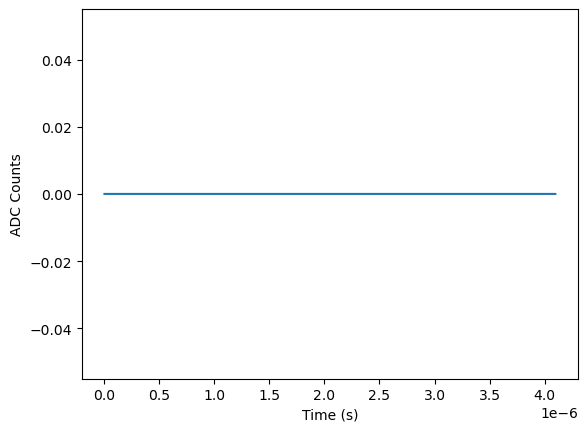

In [41]:
plt.figure()
plt.xlabel('Time (s)')
plt.ylabel('ADC Counts')
plt.plot(np.arange(0,acq_data['0'].shape[1]*0.5e-9,0.5e-9)[10:], np.average(acq_data['0'],axis=0)[10:])

### 2.2 Gate generation
Define a circuit with calibrated gates / parameters.

In [9]:
circuit_2 = [
    
    # play a pi/2 pulse on Q3
    {'name': 'X90', 'qubit': 'Q0', 'modi':{(0, 'amp'): 0.80, (0, 'freq'): 400e6}},
    
    # play two pi/2 pulses on Q3 and Q6 simultaneously
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'X90', 'qubit': 'Q6'},
    
    # add delay
    {'name': 'delay', 't': 200.e-9}, 
    
    # play a CNOT gate on Q3 and Q6
    {'name': 'CNOT', 'qubit': ['Q3','Q6']},
    
    # schedule barrier
    {'name': 'barrier', 'qubit': ['Q0','Q6']},
    
    # play readout gates for measurement
    {'name': 'read', 'qubit': 'Q0'},
    {'name': 'read', 'qubit': 'Q6'}
    
]

In [10]:
compiled_prog = tc.run_compile_stage(circuit_2, fpga_config, qchip)
raw_asm = tc.run_assemble_stage(compiled_prog, channel_configs)

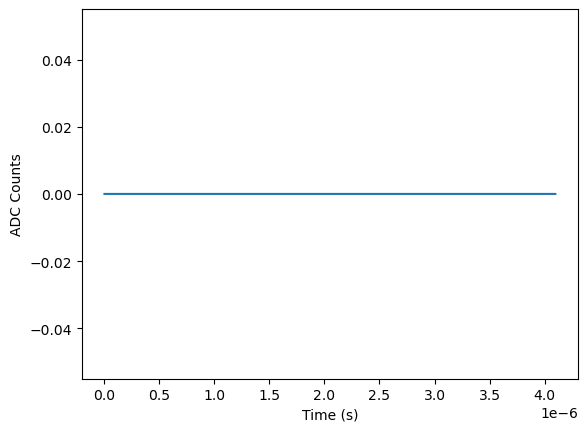

In [11]:
acq_data = runner.load_and_run_acq(raw_asm, n_total_shots=1, acq_chans={'0':0,'1':1}, trig_delay=0e-9)
plt.figure()
plt.xlabel('Time (s)')
plt.ylabel('ADC Counts')
plt.plot(np.arange(0,acq_data['1'].shape[1]*0.5e-9,0.5e-9)[10:], np.average(acq_data['1'],axis=0)[10:])

### 2.3 Circuit generation
Now it is the time to create your own quantum circuit and capture it through the acq buffer.

In [12]:
circuit_3 = []

In [13]:
compiled_prog = tc.run_compile_stage(circuit_3, fpga_config, qchip)
raw_asm = tc.run_assemble_stage(compiled_prog, channel_configs)

IndexError: list index out of range

In [ ]:
acq_data = runner.load_and_run_acq(raw_asm, n_total_shots=1, acq_chans={'0':0,'1':1}, trig_delay=0e-9)
plt.figure()
plt.xlabel('Time (s)')
plt.ylabel('ADC Counts')
plt.plot(np.arange(0,acq_data['1'].shape[1]*0.5e-9,0.5e-9)[10:], np.average(acq_data['1'],axis=0)[10:])

## 3. VNA test
Perform frequency sweeps while obtaining amplitude and phase responses in loopback mode, resembling the capabilities of a vector network analyzer (VNA). This dedicated tool is instrumental for conducting qubit readout spectroscopy. 

![vna.svg](./images/vna.svg)

In [140]:
import qubic.results as rs

In [55]:
amp = 0.99
freqs = np.linspace(1.0e9, 5.0e9, 100)
nshots = 20
from importlib import reload; reload(vn)
vna = vn.Vna(amp, freqs, nshots)
jobman = jm.JobManager(fpga_config, channel_configs, runner, qchip)
vna.run_and_report(jobman)

JobManager class is for compiling and executing circuits, which contains necessary config objects for compilation, runner for execution, and (optionally) GMMManager for state classification.

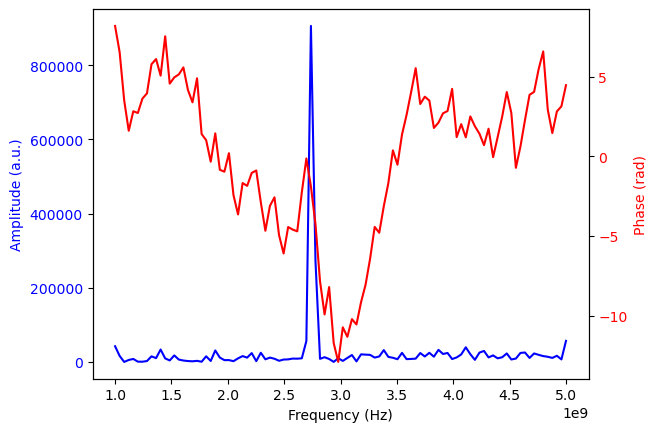

In [56]:
fig, ax1 = plt.subplots()
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Amplitude (a.u.)', color='b')
ax1.plot(vna.freqs, vna.results['amp'], color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.set_ylabel('Phase (rad)', color='r')
ax2.plot(freqs, vna.results['phase'], color='r')
ax2.tick_params(axis='y', labelcolor='r')

## 4. Readout emulator and GMM fitting
### Create a qubit readout emulator with RF components to mimic the quantum signal processing.

![readout_emulator.svg](./images/readout_emulator.svg)

In [147]:
fread=2.7568e9
circuit_4 = [
    {'name': 'read', 'qubit': 'Q3', 
     'modi':{(0, 'amp'): 0.99, (0, 'freq'): fread, (1, 'freq'): fread, (1, 'phase'): 0}}
]

In [148]:
compiled_prog = tc.run_compile_stage(circuit_4, fpga_config, qchip)
raw_asm = tc.run_assemble_stage(compiled_prog, channel_configs)
s11 = runner.run_circuit_batch([raw_asm], 5000)

In [149]:
s11

[{'Q3.rdlo': S11([[1429287.+954559.j]
   [1383120.+952507.j]
   [1368430.+966748.j]
   ...
   [1540784.+158380.j]
   [1561000.+170047.j]
   [1550936.+171295.j]])}]

A dictionary of downconverted + integrated complex (IQ) values is returned for each loaded channel. Here, we are using Q3.

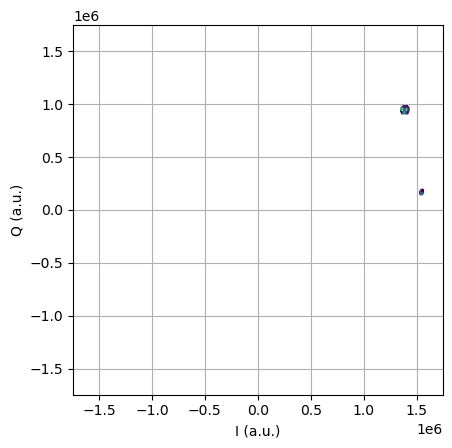

In [150]:
plt.figure()
ax1 = plt.subplot(111)
ax1.set_aspect('equal')
ax1.hexbin(s11[0]['Q3.rdlo'].real, s11[0]['Q3.rdlo'].imag, gridsize=50, mincnt=20)
lim = max(1.1*max(max(abs(s11[0]['Q3.rdlo'].real)), max(abs(s11[0]['Q3.rdlo'].imag))), 0.1)
ax1.set_xlim([-lim,lim])
ax1.set_ylim([-lim,lim])
ax1.set_xlabel('I (a.u.)')
ax1.set_ylabel('Q (a.u.)')
plt.grid()

### Fit the two blobs with Gaussian Mixture Model (GMM).

In [151]:
gmm_manager = sd.GMMManager(chanmap_or_chan_cfgs=channel_configs)
s11 = rs.tools.pack_s11_results(s11)
gmm_manager.fit(s11)
gmm_manager.gmm_dict['Q3'].gmmfit.means_

array([[1388596.17333984,  944690.45922852],
       [1547504.20353982,  166405.0199115 ]])

### Rotate the blobs on the IQ plane to create a decision boundary along the Y-axis.

In [152]:
gmm_manager.set_labels_maxtomin(s11, [0, 1])
angle = gmm_manager.get_threshold_angle('Q3')
circuit_5 = [
    {'name': 'read', 'qubit': 'Q3',
     'modi':{(0, 'amp'): 0.99, (0, 'freq'): fread, (1, 'freq'): fread, (1, 'phase'): np.pi/2-angle}}
]

In [155]:
compiled_prog = tc.run_compile_stage(circuit_5, fpga_config, qchip)
raw_asm = tc.run_assemble_stage(compiled_prog, channel_configs)
s11 = runner.run_circuit_batch([raw_asm], 5000)
s11 = rs.tools.pack_s11_results(s11)

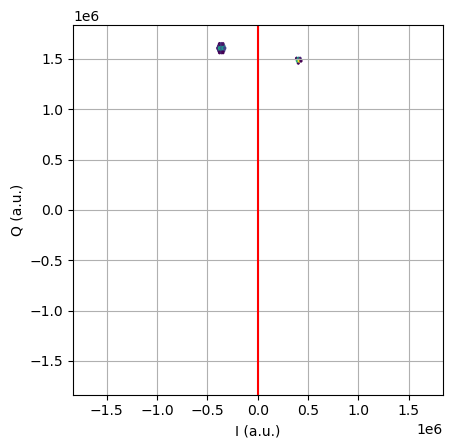

In [156]:
gmm_manager = sd.GMMManager(chanmap_or_chan_cfgs=channel_configs)
gmm_manager.fit(s11)
plt.figure()
ax1=plt.subplot(111)
ax1.set_aspect('equal')
ax1.hexbin(s11['Q3.rdlo'].real[0], s11['Q3.rdlo'].imag[0], gridsize=50, mincnt=20)
lim=max(1.1*max(max(abs(s11['Q3.rdlo'].real[0])),max(abs(s11['Q3.rdlo'].imag[0]))),0.1)
ax1.set_xlim([-lim,lim])
ax1.set_ylim([-lim,lim])
ax1.set_xlabel('I (a.u.)')
ax1.set_ylabel('Q (a.u.)')
plt.axvline(x=0, color='r')
plt.grid()

Let's designate the left blob as state |0⟩ and the right blob as state |1⟩.

In [157]:
gmm_manager.set_labels_maxtomin(s11, [0, 1])
if gmm_manager.gmm_dict['Q3'].gmmfit.means_[gmm_manager.gmm_dict['Q3'].labels.tolist().index(0.)][0] > 0:
    gmm_manager.gmm_dict['Q3'].switch_labels()

## 5. Fast feedback - Active reset
Active reset is a fast feedback technique utilized to swiftly and efficiently restore a quantum system to a well-defined initial state, commonly the ground state. The method involves a single-shot measurement of the qubit state, followed by a conditional single-qubit gate operation. If the qubit is found in an excited state, this gate operation rotates it into the ground state.
### Implement active reset circuit.

In [158]:
cond_lhs = 0
circuit_6 = [
    {'name': 'X90', 'qubit': 'Q3', 'modi':{(0, 'amp'): 0.19, (0, 'freq'): 400e6}},
    {'name': 'read', 'qubit': 'Q3', 
     'modi':{(0, 'amp'): 0.99, (0, 'freq'): fread, (1, 'freq'): fread, (1, 'phase'): np.pi/2-angle}},
    {'name': 'branch_fproc', 'alu_cond': 'eq', 'cond_lhs': cond_lhs, 'func_id': 'Q3.meas', 'scope': ['Q3'],
                'true': [{'name': 'delay', 't': 200.e-9, 'qubit': 'Q3'},
                         {'name': 'X90', 'qubit': 'Q3', 'modi':{(0, 'amp'): 0.99, (0, 'freq'): 400e6}}, 
                         {'name': 'X90', 'qubit': 'Q3', 'modi':{(0, 'amp'): 0.99, (0, 'freq'): 400e6}}], 
                'false': []},
]

### Perform single-shot measurement.

In [159]:
compiled_prog = tc.run_compile_stage(circuit_6, fpga_config, qchip)
raw_asm = tc.run_assemble_stage(compiled_prog, channel_configs)
acq_data = runner.load_and_run_acq(raw_asm, n_total_shots=1, acq_chans={'0':0,'1':1}, trig_delay=0e-9, return_acc=True)
print(acq_data)
gmm_manager.predict(acq_data[1])

({'0': array([[    0, 32767,     0, ...,     0,     0,     0]], dtype=int32), '1': array([[    0, 32767,     0, ...,     0,     0,     0]], dtype=int32)}, {'Q3.rdlo': array([-350670.+1656889.j])})


{'Q3': array([0.])}

### Check the conditional gate operation through the acq buffer.

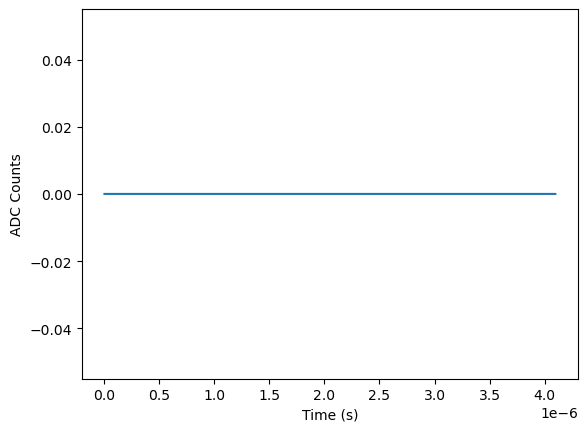

In [160]:
plt.figure()
plt.xlabel('Time (s)')
plt.ylabel('ADC Counts')
plt.plot(np.arange(0,acq_data[0]['1'].shape[1]*0.5e-9,0.5e-9)[10:], np.average(acq_data[0]['1'],axis=0)[10:])